<a href="https://colab.research.google.com/github/isil-ada/derinogrenme4/blob/main/Bitki_Hastalik_Tespiti_CNN_vs_ViT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌿 Bitki Hastalığı Tespiti: EfficientNet (CNN) vs. Vision Transformer (ViT)
Bu notebook, bitki yapraklarındaki hastalıkları tespit etmek için iki modern derin öğrenme mimarisini uçtan uca (end-to-end) karşılaştırır:
1. **EfficientNet-B0** — CNN tabanlı, düşük parametreli, hızlı
2. **ViT-B/16** — Transformer tabanlı, dikkat mekanizmalı

**Veri Seti:** `emmarex/plantdisease` (Kaggle)


## 1. Ortam Kurulumu ve Kaggle Veri Seti İndirme


In [1]:
# Gerekli paketlerin kurulumu
!pip install -q kaggle

import os

# ========================================================
# KAGGLE API KİMLİK BİLGİLERİ (Placeholder)
# Kendi Kaggle bilgilerinizi buraya giriniz.
# ========================================================
os.environ['KAGGLE_USERNAME'] = "senafg"
os.environ['KAGGLE_KEY'] = "KGAT_f69c9e0f1620f1db85819b9aa82a4209"

# Veri setini Kaggle'dan indir
!kaggle datasets download -d emmarex/plantdisease

# ./data klasörüne zipten çıkar
!mkdir -p ./data
!unzip -q plantdisease.zip -d ./data

print("Veri seti başarıyla indirildi ve çıkarıldı.")


Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:38<00:00, 18.0MB/s]

Veri seti başarıyla indirildi ve çıkarıldı.


## 2. Kütüphanelerin İçe Aktarılması ve GPU Kontrolü


In [2]:
import time, copy, os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

# ========================================================
# GPU (CUDA) KONTROLÜ
# Colab'da Çalışma Zamanı > Çalışma zamanı türünü değiştir
# menüsünden T4 GPU seçtiğinizden emin olun.
# ========================================================
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU Aktif: {torch.cuda.get_device_name(0)}")
    print(f"GPU Belleği: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    device = torch.device("cpu")
    print("UYARI: GPU bulunamadı! Eğitim CPU üzerinde çok yavaş olacaktır.")
    print("Lütfen Çalışma Zamanı > Türü Değiştir > GPU seçin.")


GPU Aktif: NVIDIA A100-SXM4-80GB
GPU Belleği: 85.1 GB


## 3. Veri Ön İşleme ve DataLoader Hazırlığı
- **Eğitim:** Resize(224), RandomRotation, HorizontalFlip, ImageNet Normalizasyonu
- **Test:** Resize(224), ImageNet Normalizasyonu
- **Bölme:** %80 Eğitim / %20 Test


In [3]:
# Veri dizini (zip yapısına göre ayarlayın)
data_dir = './data/PlantVillage'
if not os.path.exists(data_dir):
    data_dir = './data'

# ========================================================
# DÖNÜŞÜMLER (TRANSFORMS)
# Eğitim: Veri artırma (augmentation) ile overfitting'i azalt
# Test: Sadece boyutlandırma ve normalizasyon
# ========================================================
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ImageFolder ile veri yükleme
full_train_dataset = datasets.ImageFolder(data_dir, transform=train_transforms)
full_test_dataset  = datasets.ImageFolder(data_dir, transform=test_transforms)

class_names = full_train_dataset.classes
num_classes = len(class_names)

# %80 Eğitim, %20 Test rastgele bölme
total_size = len(full_train_dataset)
torch.manual_seed(42)
indices = torch.randperm(total_size).tolist()
train_size = int(0.8 * total_size)

train_dataset = Subset(full_train_dataset, indices[:train_size])
test_dataset  = Subset(full_test_dataset,  indices[train_size:])

batch_size = 64
dataloaders = {
    'train': DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2),
    'valid': DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2)
}
dataset_sizes = {'train': len(train_dataset), 'valid': len(test_dataset)}

print(f"Sınıf Sayısı  : {num_classes}")
print(f"Eğitim Verisi : {dataset_sizes['train']}")
print(f"Test Verisi   : {dataset_sizes['valid']}")


Sınıf Sayısı  : 15
Eğitim Verisi : 16510
Test Verisi   : 4128


## 4. Eğitim Döngüsü (Training Loop)


In [4]:
def train_model(model, criterion, optimizer, num_epochs=10):
    """
    Modeli eğitir, her epoch'ta loss/accuracy takip eder,
    en iyi ağırlıkları kaydeder ve eğitim süresini döndürür.
    """
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {'train_loss':[], 'valid_loss':[], 'train_acc':[], 'valid_acc':[]}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 30)

        for phase in ['train', 'valid']:
            model.train() if phase == 'train' else model.eval()
            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc  = running_corrects.double() / dataset_sizes[phase]
            print(f'  {phase.capitalize():5s} -> Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}')

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            # En iyi modeli kaydet
            if phase == 'valid' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
        print()

    elapsed = time.time() - since
    print(f'Eğitim Süresi: {elapsed//60:.0f}dk {elapsed%60:.0f}sn | En İyi Val Acc: {best_acc:.4f}')
    model.load_state_dict(best_model_wts)
    return model, history, elapsed


## 5. Model 1: EfficientNet-B0 (CNN)
Pre-trained ağırlıklar yüklenip son sınıflandırıcı katman güncelleniyor.


In [5]:
# EfficientNet-B0: Pre-trained yükleme + sınıflandırıcı güncelleme
efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
efficientnet.classifier[1] = nn.Linear(efficientnet.classifier[1].in_features, num_classes)
efficientnet = efficientnet.to(device)

# Optimizer ve Loss
criterion = nn.CrossEntropyLoss()
optimizer_eff = optim.AdamW(efficientnet.parameters(), lr=0.001, weight_decay=0.01)

total_params_eff = sum(p.numel() for p in efficientnet.parameters())
print(f"EfficientNet-B0 Hazır | Parametre: {total_params_eff:,}")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 213MB/s]


EfficientNet-B0 Hazır | Parametre: 4,026,763


### EfficientNet Eğitimi


In [6]:
epochs = 5
print("EfficientNet Eğitimi Başlıyor...")
efficientnet, hist_eff, time_eff = train_model(efficientnet, criterion, optimizer_eff, num_epochs=epochs)


EfficientNet Eğitimi Başlıyor...
Epoch 1/5
------------------------------
  Train -> Loss: 0.2314  Acc: 0.9344
  Valid -> Loss: 0.0707  Acc: 0.9797

Epoch 2/5
------------------------------
  Train -> Loss: 0.0757  Acc: 0.9762
  Valid -> Loss: 0.0360  Acc: 0.9896

Epoch 3/5
------------------------------
  Train -> Loss: 0.0473  Acc: 0.9845
  Valid -> Loss: 0.0483  Acc: 0.9862

Epoch 4/5
------------------------------
  Train -> Loss: 0.0363  Acc: 0.9889
  Valid -> Loss: 0.0373  Acc: 0.9881

Epoch 5/5
------------------------------
  Train -> Loss: 0.0313  Acc: 0.9906
  Valid -> Loss: 0.0605  Acc: 0.9816

Eğitim Süresi: 2dk 50sn | En İyi Val Acc: 0.9896


## 6. Model 2: Vision Transformer (ViT-B/16)
Pre-trained ağırlıklar yüklenip sınıflandırıcı head güncelleniyor.


In [7]:
# ViT-B/16: Pre-trained yükleme + head güncelleme
vit = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
vit.heads.head = nn.Linear(vit.heads.head.in_features, num_classes)
vit = vit.to(device)

optimizer_vit = optim.AdamW(vit.parameters(), lr=0.0001, weight_decay=0.01)

total_params_vit = sum(p.numel() for p in vit.parameters())
print(f"ViT-B/16 Hazır | Parametre: {total_params_vit:,}")


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 240MB/s]


ViT-B/16 Hazır | Parametre: 85,810,191


### ViT Eğitimi


In [8]:
print("Vision Transformer (ViT) Eğitimi Başlıyor...")
vit, hist_vit, time_vit = train_model(vit, criterion, optimizer_vit, num_epochs=epochs)


Vision Transformer (ViT) Eğitimi Başlıyor...
Epoch 1/5
------------------------------
  Train -> Loss: 0.2395  Acc: 0.9298
  Valid -> Loss: 0.0687  Acc: 0.9777

Epoch 2/5
------------------------------
  Train -> Loss: 0.0445  Acc: 0.9855
  Valid -> Loss: 0.0505  Acc: 0.9830

Epoch 3/5
------------------------------
  Train -> Loss: 0.0344  Acc: 0.9896
  Valid -> Loss: 0.0353  Acc: 0.9896

Epoch 4/5
------------------------------
  Train -> Loss: 0.0330  Acc: 0.9901
  Valid -> Loss: 0.0317  Acc: 0.9872

Epoch 5/5
------------------------------
  Train -> Loss: 0.0290  Acc: 0.9921
  Valid -> Loss: 0.0407  Acc: 0.9886

Eğitim Süresi: 10dk 16sn | En İyi Val Acc: 0.9896


## 7. Accuracy ve Loss Grafiklerinin Karşılaştırılması


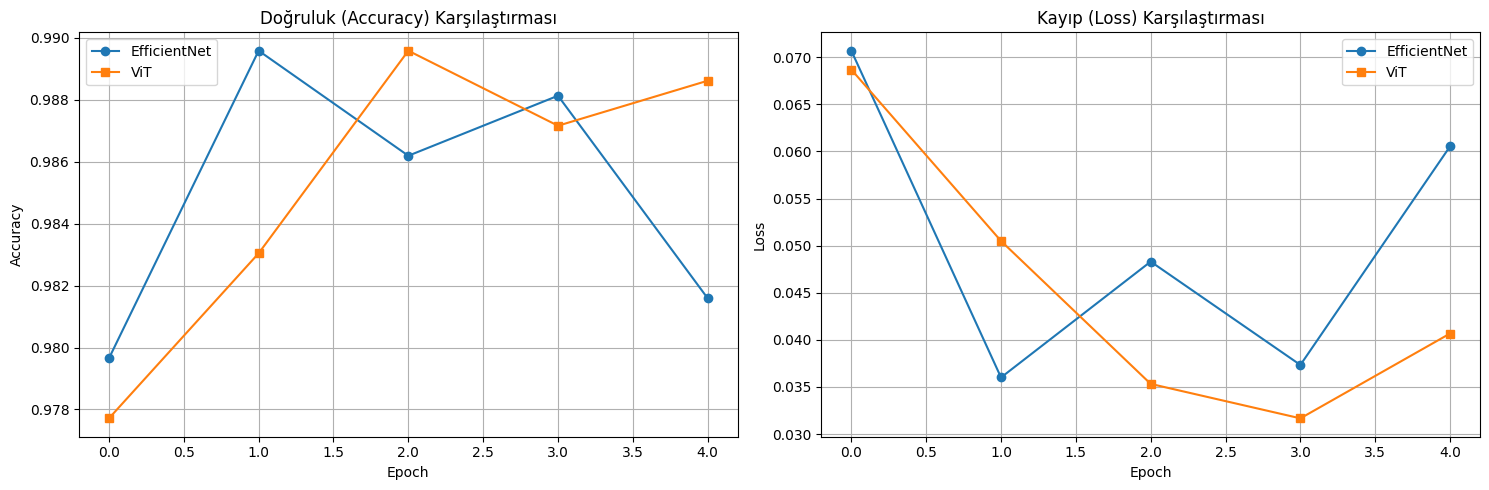

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(hist_eff['valid_acc'], label='EfficientNet', marker='o')
axes[0].plot(hist_vit['valid_acc'], label='ViT', marker='s')
axes[0].set_title('Doğruluk (Accuracy) Karşılaştırması')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

# Loss
axes[1].plot(hist_eff['valid_loss'], label='EfficientNet', marker='o')
axes[1].plot(hist_vit['valid_loss'], label='ViT', marker='s')
axes[1].set_title('Kayıp (Loss) Karşılaştırması')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()


## 8. Confusion Matrix (Karmaşıklık Matrisi)


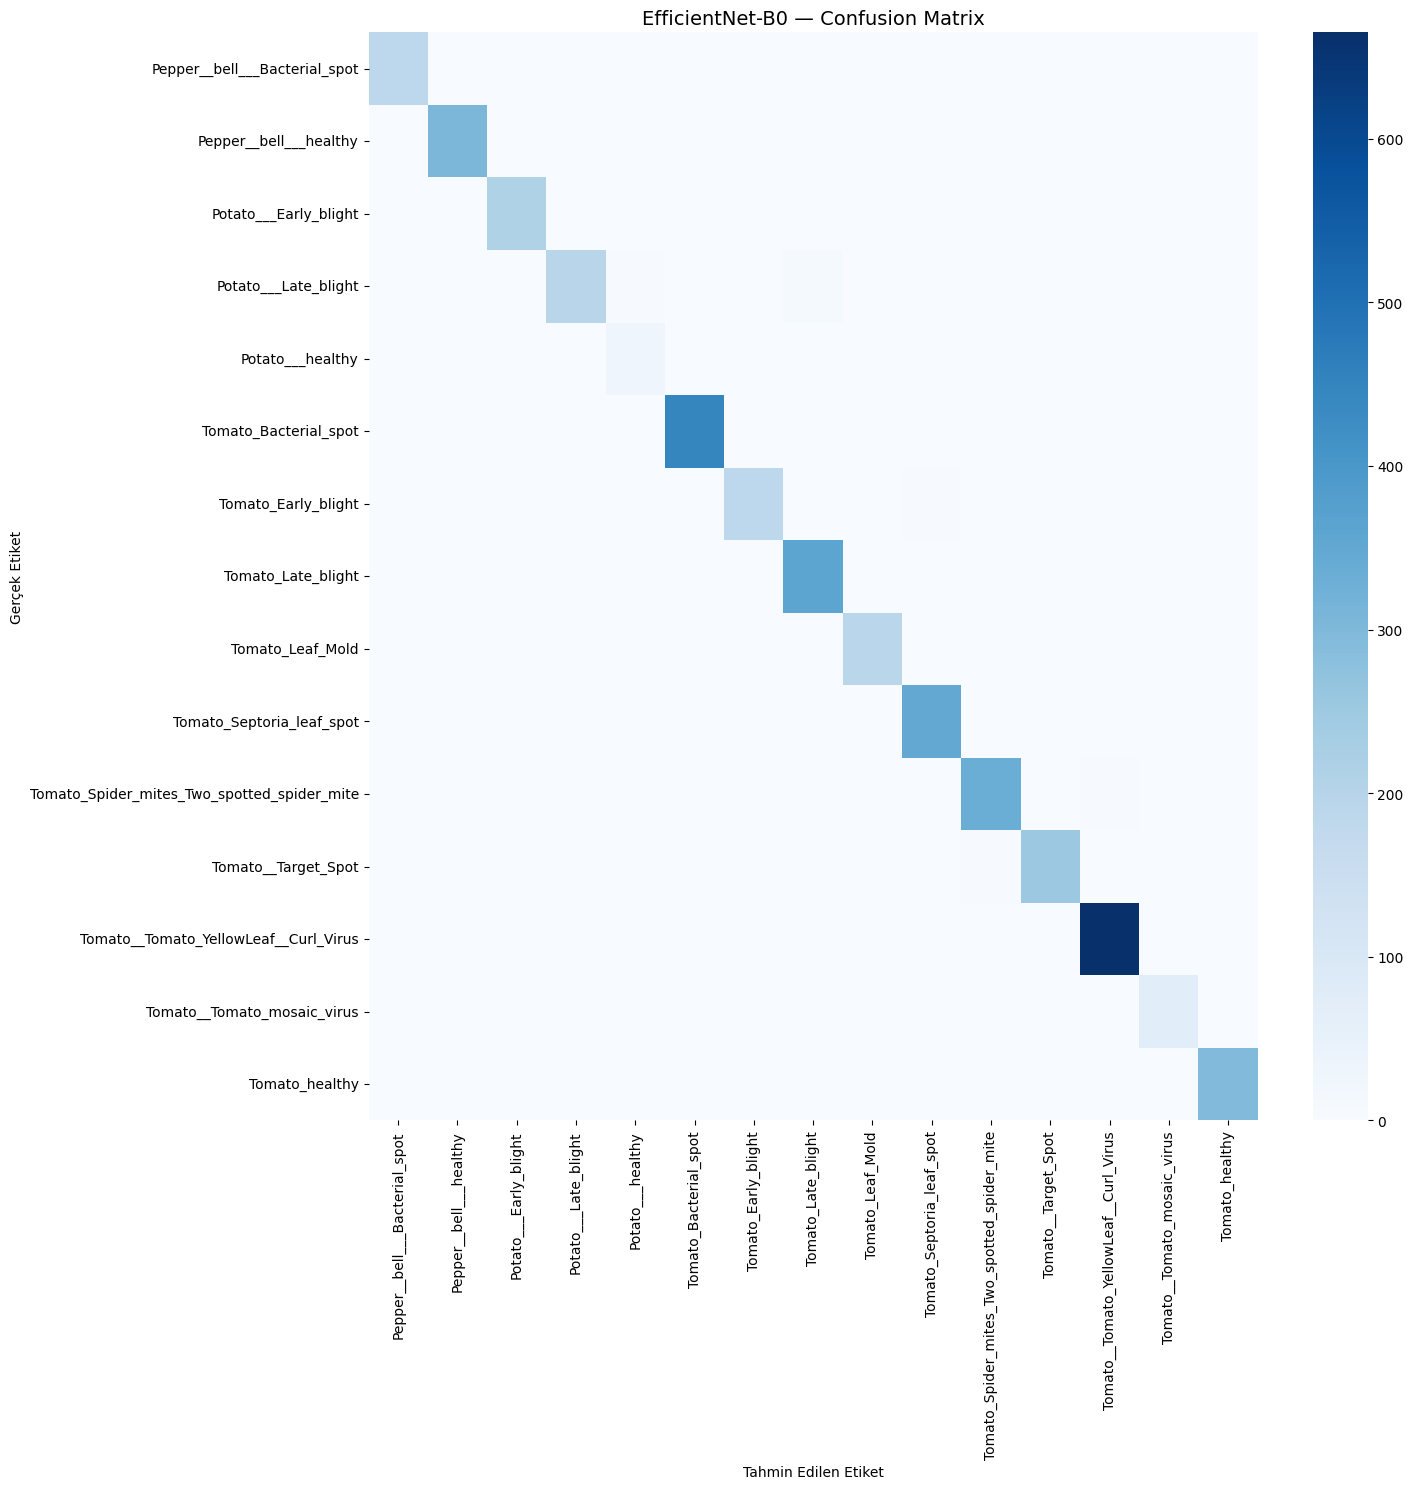

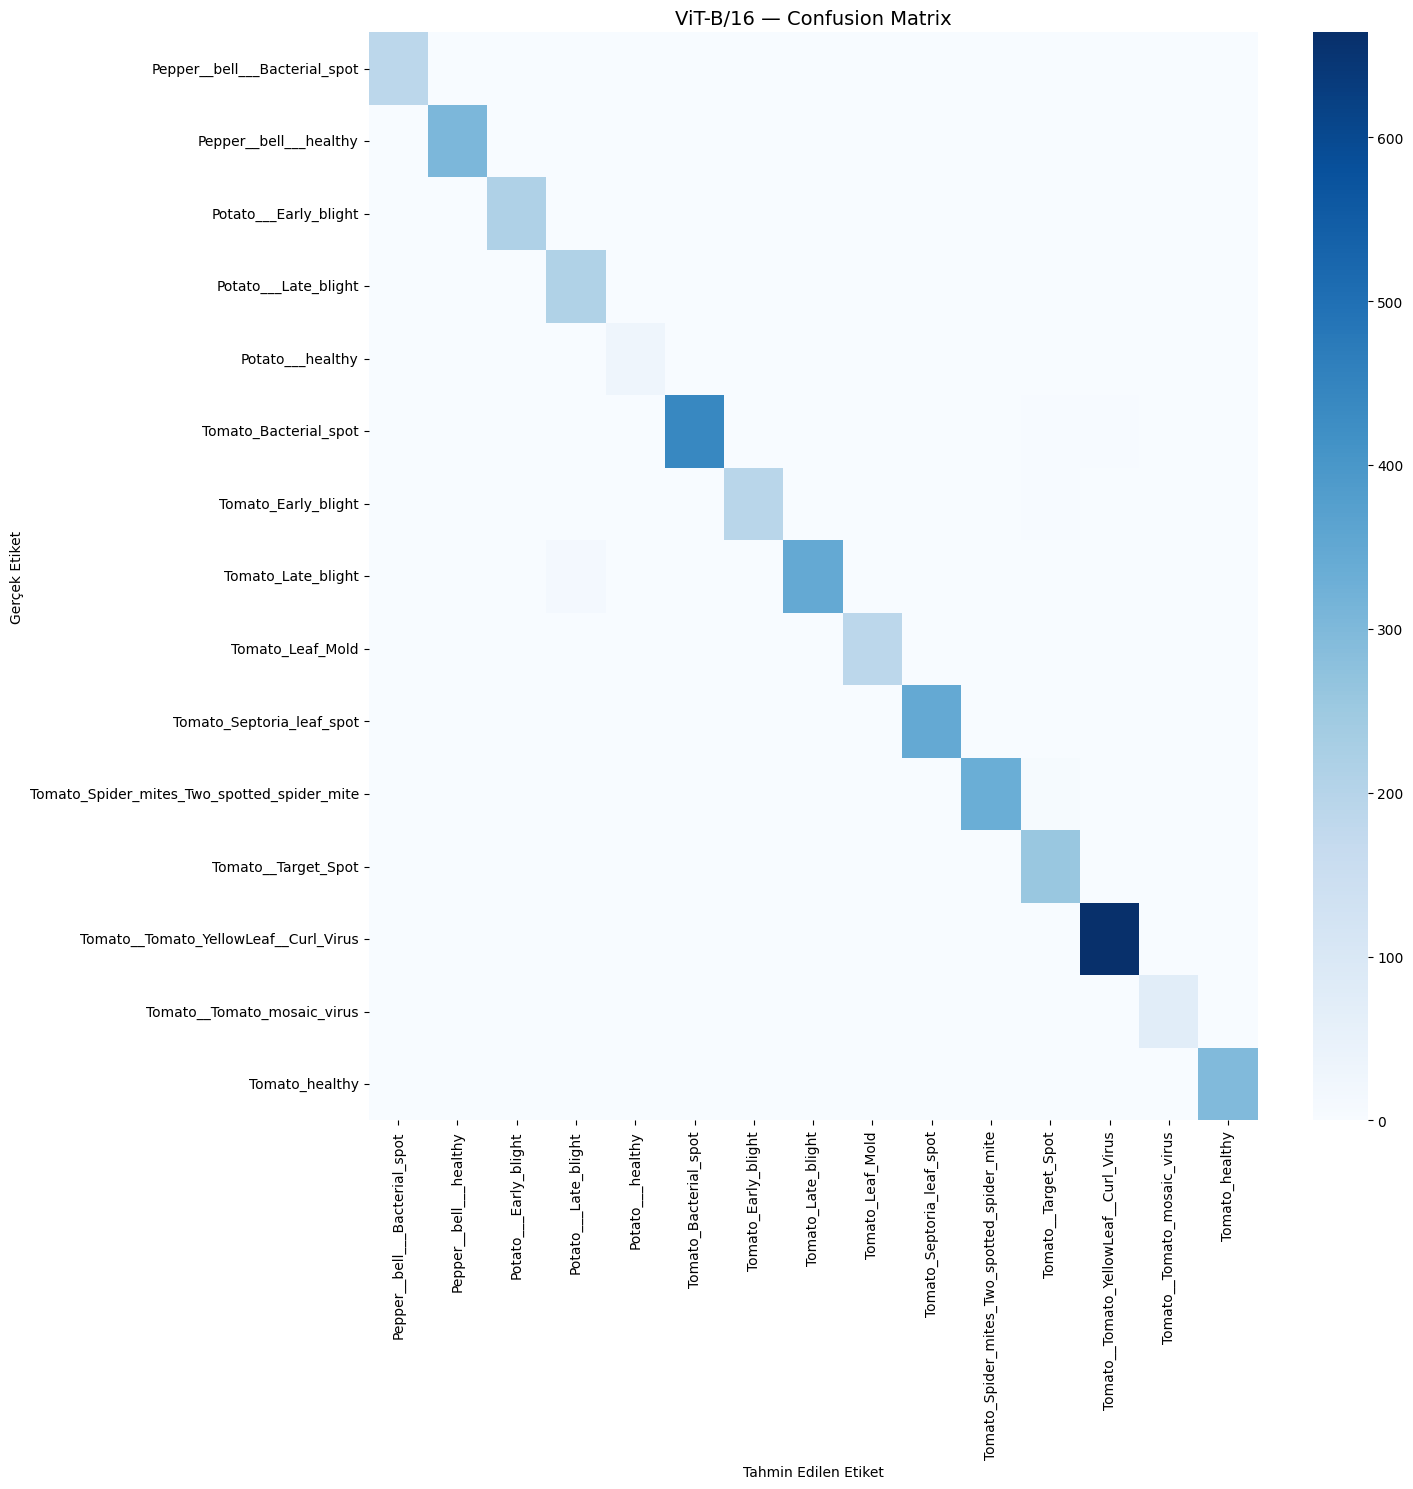


EfficientNet Sınıflandırma Raporu:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       1.00      0.99      1.00       188
                     Pepper__bell___healthy       1.00      1.00      1.00       307
                      Potato___Early_blight       1.00      1.00      1.00       214
                       Potato___Late_blight       1.00      0.93      0.97       211
                           Potato___healthy       0.91      1.00      0.95        30
                      Tomato_Bacterial_spot       1.00      1.00      1.00       448
                        Tomato_Early_blight       1.00      0.94      0.97       196
                         Tomato_Late_blight       0.96      0.99      0.98       361
                           Tomato_Leaf_Mold       0.97      0.99      0.98       191
                  Tomato_Septoria_leaf_spot       0.98      1.00      0.99       349
Tomato_Spider_mites_Two_spot

In [10]:
def evaluate_model(model, dataloader):
    """Test verisi üzerinde tahmin yaparak gerçek ve tahmin etiketlerini döndürür."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            _, preds = torch.max(model(inputs), 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

y_true, y_pred_eff = evaluate_model(efficientnet, dataloaders['valid'])
_, y_pred_vit = evaluate_model(vit, dataloaders['valid'])

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(15, 15))
    sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title, fontsize=14)
    plt.ylabel('Gerçek Etiket'); plt.xlabel('Tahmin Edilen Etiket')
    plt.xticks(rotation=90); plt.tight_layout(); plt.show()

plot_cm(y_true, y_pred_eff, 'EfficientNet-B0 — Confusion Matrix')
plot_cm(y_true, y_pred_vit, 'ViT-B/16 — Confusion Matrix')

print("\nEfficientNet Sınıflandırma Raporu:")
print(classification_report(y_true, y_pred_eff, target_names=class_names))
print("\nViT Sınıflandırma Raporu:")
print(classification_report(y_true, y_pred_vit, target_names=class_names))


## 9. Özet Karşılaştırma Tablosu


In [11]:
params_eff = sum(p.numel() for p in efficientnet.parameters())
params_vit = sum(p.numel() for p in vit.parameters())
best_eff = max(hist_eff['valid_acc'])
best_vit = max(hist_vit['valid_acc'])

print("=" * 75)
print("              MODEL KARŞILAŞTIRMA TABLOSU")
print("=" * 75)
print(f"{'Model':<25} {'Parametre':<18} {'Eğitim Süresi':<18} {'En İyi Acc':<12}")
print("-" * 75)
print(f"{'EfficientNet-B0':<25} {params_eff:>14,}   {time_eff//60:.0f}dk {time_eff%60:.0f}sn{'':<8} {best_eff:.4f}")
print(f"{'ViT-B/16':<25} {params_vit:>14,}   {time_vit//60:.0f}dk {time_vit%60:.0f}sn{'':<8} {best_vit:.4f}")
print("=" * 75)

if best_eff > best_vit:
    print(f"Sonuç: EfficientNet-B0, {best_eff - best_vit:.4f} fark ile daha iyi performans gösterdi.")
elif best_vit > best_eff:
    print(f"Sonuç: ViT-B/16, {best_vit - best_eff:.4f} fark ile daha iyi performans gösterdi.")
else:
    print("Sonuç: Her iki model aynı doğruluk değerine ulaştı.")


              MODEL KARŞILAŞTIRMA TABLOSU
Model                     Parametre          Eğitim Süresi      En İyi Acc  
---------------------------------------------------------------------------
EfficientNet-B0                4,026,763   2dk 50sn         0.9896
ViT-B/16                      85,810,191   10dk 16sn         0.9896
Sonuç: Her iki model aynı doğruluk değerine ulaştı.
